Final Notebook: it loads the cleaned dataset from Session 4 and walks through problem → method → findings → limitations → conclusion.


Problem statement and hypotheses

Eurovision is watched by roughly 160 million people, and every year the press claims it "launches careers." We tested that claim with data.

Research question: For Eurovision top-10 finishers from 2015 to 2025, does their music-release rate increase in the years after the contest compared to the years before?

Hypotheses
- H1 — Top-3 finishers release at least 1.5× more music per year after Eurovision.
- H2 — Winners get a bigger bump than runners-up.
- H3 — Newer artists (active < 2 years) get a bigger relative bump than long-established ones.


Data sources and methodology

Two independent sources (MusicBrainz and Wikipedia), combined on the artist name. For Music Brainz we used a public API (requests) while for Wikipedia we used scraping. Using the API it gaves us the full release discorapgy for each artist (and the release date) while scraping with BeautifulSoup gave us the artist bios: career start, genre, origin.

Pipeline: 100 top-10 finishers → MusicBrainz API for discographies → Wikipedia scrape for bios → clean (parse dates, keep official releases, dedupe) → engineer releases-per-year before vs after → one analytical table.

Key design choice: we measure rates (releases per year), not raw counts, so a 2015 artist with 10 years of "after" data isn't unfairly compared to a 2023 one. We report the median per group because with roughly 10 artists per group, the mean is distorted by a few very prolific acts.


Load the clean data

In [1]:
from google.colab import files
uploaded = files.upload()

Saving clean_artists_20260522_083307 (1).csv to clean_artists_20260522_083307 (1).csv
Saving clean_releases_20260522_083307 (1).csv to clean_releases_20260522_083307 (1).csv


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
CB = {"grey":"#999999","pink":"#CC79A7","blue":"#0072B2","orange":"#E69F00","verm":"#D55E00","sky":"#56B4E9"}
SOURCE = "Source: MusicBrainz API + Wikipedia (2015-2025), collected by the authors."
sns.set_style("whitegrid")

artists  = pd.read_csv([n for n in uploaded if "artists" in n][0])
releases = pd.read_csv([n for n in uploaded if "releases" in n][0])
artists["bump_ratio"] = artists["bump_ratio"].replace([np.inf,-np.inf], np.nan)
ORDER = ["Winner","Runner-up","Top-10"]
bumpable = artists[(artists["enough_after_data"]==True) & (artists["bump_ratio"].notna())].copy()
print(f"{len(artists)} artists, {len(bumpable)} usable for the bump analysis.")

83 artists, 59 usable for the bump analysis.


Key findings

Finding 1: Eurovision is a short-term launch spike, not a permanent change

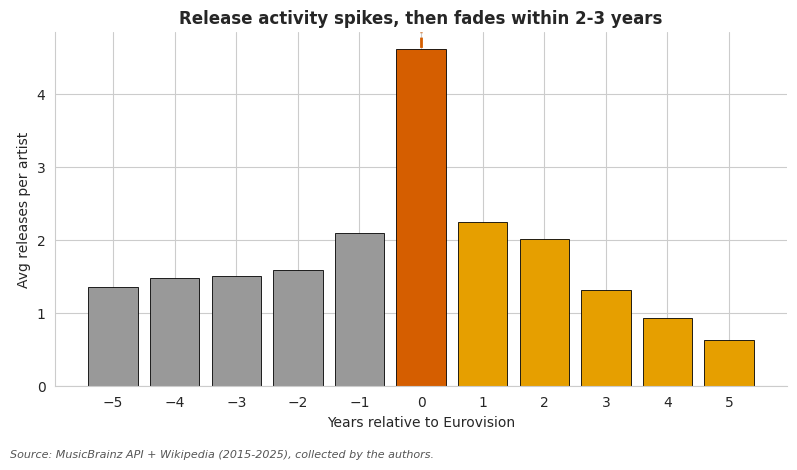

In [3]:
releases["offset"] = releases["release_year"] - releases["event_year"]
w = releases[releases["offset"].between(-5,5)]
per = w.groupby("offset").size() / artists["artist"].nunique()
fig,ax=plt.subplots(figsize=(8,4.5))
cols=[CB["grey"] if o<0 else (CB["verm"] if o==0 else CB["orange"]) for o in per.index]
ax.bar(per.index, per.values, color=cols, edgecolor="black", linewidth=0.6)
ax.axvline(0,color=CB["verm"],ls="--",lw=2)
ax.set_xlabel("Years relative to Eurovision"); ax.set_ylabel("Avg releases per artist")
ax.set_title("Release activity spikes, then fades within 2-3 years", weight="bold")
ax.set_xticks(range(-5,6)); sns.despine()
fig.text(0.01,-0.03,SOURCE,fontsize=8,style="italic",color="#555555")
plt.tight_layout(); plt.show()

Activity sits around 1.5 releases/year before the contest, spikes to roughly 4.6 in the Eurovision year, stays elevated (2.2 and 2.0) for two years, then falls back. Eurovision is a launch moment, not a slow burn.

Finding 2: The bump is real on average but far from universal

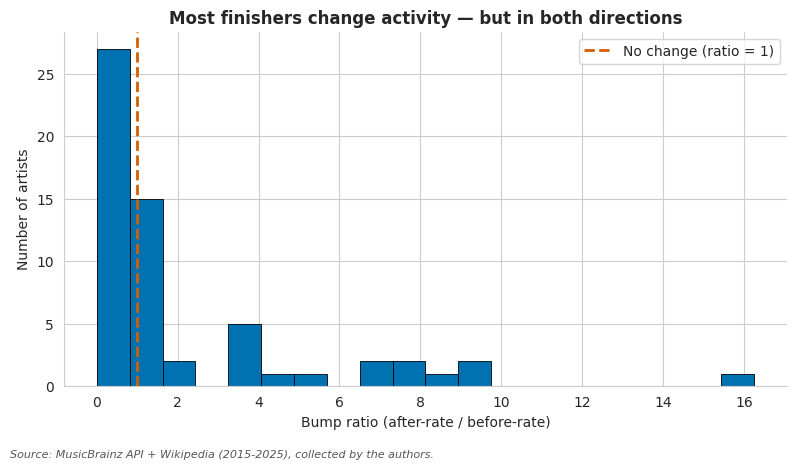

In [4]:
fig,ax=plt.subplots(figsize=(8,4.5))
ax.hist(bumpable["bump_ratio"], bins=20, color=CB["blue"], edgecolor="black", linewidth=0.6)
ax.axvline(1.0,color=CB["verm"],ls="--",lw=2,label="No change (ratio = 1)")
ax.set_xlabel("Bump ratio (after-rate / before-rate)"); ax.set_ylabel("Number of artists")
ax.set_title("Most finishers change activity — but in both directions", weight="bold")
ax.legend(); sns.despine()
fig.text(0.01,-0.03,SOURCE,fontsize=8,style="italic",color="#555555")
plt.tight_layout(); plt.show()

The distribution is heavily right-skewed: many artists actually release less afterwards (ratio < 1), while a smaller group sees big jumps that pull the average up. The "career launch" is real for some, not all.

Finding 3: The bump concentrates at the podium

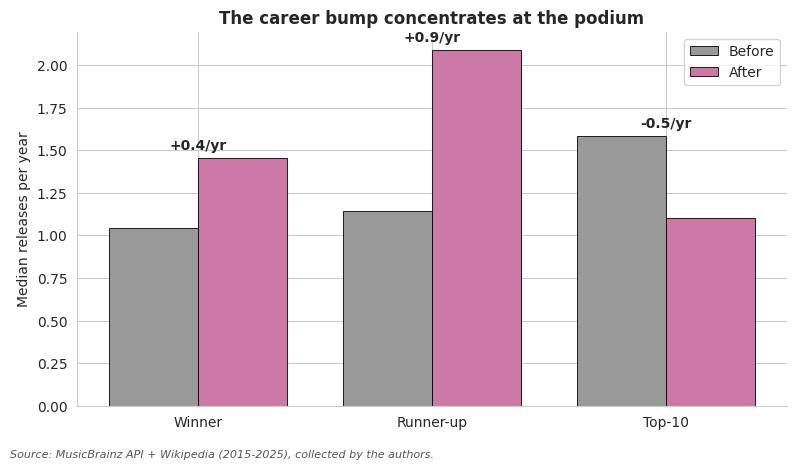

In [5]:
d = bumpable.groupby("rank_group")[["releases_per_year_before","releases_per_year_after"]].median().reindex(ORDER)
fig,ax=plt.subplots(figsize=(8,4.5))
x=np.arange(3); ww=0.38
ax.bar(x-ww/2, d["releases_per_year_before"], ww, label="Before", color=CB["grey"], edgecolor="black", linewidth=0.6)
ax.bar(x+ww/2, d["releases_per_year_after"], ww, label="After", color=CB["pink"], edgecolor="black", linewidth=0.6)
for i,g in enumerate(ORDER):
    delta=d.loc[g,"releases_per_year_after"]-d.loc[g,"releases_per_year_before"]
    ax.text(i, max(d.loc[g])+0.05, f"{delta:+.1f}/yr", ha="center", weight="bold")
ax.set_xticks(x); ax.set_xticklabels(ORDER); ax.set_ylabel("Median releases per year")
ax.set_title("The career bump concentrates at the podium", weight="bold")
ax.legend(); sns.despine()
fig.text(0.01,-0.03,SOURCE,fontsize=8,style="italic",color="#555555")
plt.tight_layout(); plt.show()

Winners (+0.4/yr) and especially runners-up (+0.9/yr) increase output; mid-table finishers (4th–10th) actually release *less* (−0.5/yr). The rank-vs-bump trend across individuals is flat (slope ≈ −0.10), so reaching the podium matters; the exact position barely does. This rejects a strict reading of H2 (winners do not get the biggest bump but runners-up do).

Biases, limitations and what we'd do with more time

- Small sample (99 artists, 10 per group). Group medians are sensitive to a handful of artists. We avoid strong causal claims.
- MusicBrainz coverage varies by country — Western-European acts are catalogued more fully, so some artists' releases are undercounted.
- Correlation, not causation. Artists who reach the final may already be on the rise, we can't fully separate "Eurovision caused it" from "rising stars reach Eurovision".
- Right-censoring. 2024–25 finishers have little after-data and are excluded from the bump charts.
- Genre data is incomplete — about a third of artists had no usable genre on Wikipedia ("unknown" was the largest bar).
- With more time: add streaming/chart data (Spotify monthly listeners, Official Charts) to measure success, not just activity; widen to top-20; and build a proper before/after control group of non-qualifiers.


Conclusion / takeaway

Eurovision gives top finishers a real but short-lived burst of output, concentrated among podium acts — and it's the platform, not the trophy, that matters.

For a music journalist or A&R scout: the window to capitalise on a Eurovision finish is the first two years, and the runners-up are at least as worth watching as the winners. After that, the spotlight fades, so the smart move is to sign and promote fast.
